Multi-Curve Framework for XCCY Swap Pricing — Master Thesis supervised by Prof. Kaiza Amouh, Paris Dauphine PSL 2026

In [89]:
import pandas as pd
import numpy as np
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt

In [90]:
# =============================================================================
# ÉTAPE 1 — Chargement des données Bloomberg
# On lit les 4 feuilles de l'Excel, chacune correspondant à une date de scénario.
# Chaque feuille contient 6 instruments x 9 maturités.
# =============================================================================

import pandas as pd
import numpy as np

# Dates des 4 scénarios macroéconomiques
DATES = ['2022-07-21', '2024-01-26', '2024-06-07', '2026-03-20']

SCENARIO_LABELS = {
    '2022-07-21': 'First ECB hike (Jul 2022)',
    '2024-01-26': 'ECB peak at 4.0% (Jan 2024)',
    '2024-06-07': 'First ECB cut (Jun 2024)',
    '2026-03-20': 'ECB neutral regime (Mar 2026)'
}

# Maturités disponibles dans l'Excel
TENORS = ['1M', '3M', '6M', '1Y', '2Y', '3Y', '5Y', '7Y', '10Y']

# Conversion des maturités en années décimales
def tenor_to_years(t):
    if t.endswith('M'):
        return int(t[:-1]) / 12
    elif t.endswith('Y'):
        return int(t[:-1])

TENORS_YRS = [tenor_to_years(t) for t in TENORS]

# Taux spot EUR/GBP à chaque date (source : Bloomberg EURGBP BGN Curncy)
SPOTS = {
    '2022-07-21': 0.852,
    '2024-01-26': 0.854,
    '2024-06-07': 0.850,
    '2026-03-20': 0.870
}

# Anticipations BCE via WIRP (World Interest Rate Probability, Bloomberg)
# Chaque entrée = dates en années depuis t=0, et taux implicites BCE en %
# Ces taux définissent les paliers de la step-function ESTR
WIRP = {
    '2022-07-21': {
        'dates_yrs': [0, 1.5/12, 3.5/12, 5.5/12, 7/12, 8.5/12, 10.5/12, 11.5/12],
        'rates':     [0.00, 0.487, 0.916, 1.204, 1.463, 1.295, 1.788, 1.180]
    },
    '2024-01-26': {
        'dates_yrs': [0, 1.5/12, 2.5/12, 4.5/12, 5.5/12, 7.5/12, 8.5/12, 10.5/12],
        'rates':     [3.899, 3.856, 3.681, 3.381, 3.129, 2.851, 2.680, 2.464]
    },
    '2024-06-07': {
        'dates_yrs': [0, 1.5/12, 3.5/12, 4.5/12, 6.5/12, 7.5/12, 9/12, 10.5/12],
        'rates':     [3.696, 3.643, 3.513, 3.465, 3.325, 3.294, 3.134, 3.148]
    },
    '2026-03-20': {
        'dates_yrs': [0, 1.5/12, 3/12, 4.5/12, 6/12, 7.5/12, 9.5/12],
        'rates':     [1.941, 2.142, 2.352, 2.499, 2.601, 2.659, 2.711]
    }
}

# Paramètres du swap EUR/GBP (Section 4.2 du mémoire)
NOTIONAL_EUR = 100_000_000   # 100M EUR
MATURITY     = 5.0           # 5 ans
PAYMENT_FREQ = 0.25          # Trimestriel (Act/360 EUR, Act/365 GBP)

# =============================================================================
# Chargement des feuilles Bloomberg
# Section 1 de chaque feuille : 6 instruments x 9 maturités
#   Ligne 1 : EUR OIS (ESTR)        — taux en %
#   Ligne 2 : GBP OIS (SONIA)       — taux en %
#   Ligne 3 : EUR/GBP Basis         — spread en bps
#   Ligne 4 : EUR/USD Basis         — spread en bps
#   Ligne 5 : GBP/USD Basis         — spread en bps
#   Ligne 6 : EUR/GBP Fwd outright  — taux de change forward
# =============================================================================

ROW_LABELS = ['ESTR', 'SONIA', 'EURGBP_basis',
              'EURUSD_basis', 'GBPUSD_basis', 'EURGBP_fwd']

data = {}
for date in DATES:
    df = pd.read_excel(
        'Bloomberg_Data_Collection.xlsx',
        sheet_name = date,
        header     = 4,        # ligne 5 de l'Excel = en-têtes des maturités
        index_col  = 0,
        usecols    = 'A,C,D,E,F,G,H,I,J,K'  # col A = label, C:K = 1M à 10Y
    )
    df.columns = TENORS
    df         = df.iloc[:6]
    df.index   = ROW_LABELS
    df         = df.apply(pd.to_numeric, errors='coerce')
    data[date] = df

# =============================================================================
# Affichage de vérification
# =============================================================================
for date in DATES:
    print(f"{'='*65}")
    print(f"Scénario  : {SCENARIO_LABELS[date]}")
    print(f"Spot EUR/GBP : {SPOTS[date]}")
    print(f"{'='*65}")
    print(data[date].to_string())
    print()

Scénario  : First ECB hike (Jul 2022)
Spot EUR/GBP : 0.852
                  1M       3M       6M       1Y       2Y       3Y      5Y       7Y      10Y
ESTR         -0.1240   0.0240   0.4600   0.5900   0.8600   0.9050   1.046   1.1700   1.3700
SONIA         1.5500   1.8300   2.2200   2.7700   2.5800   2.6500   2.335   2.1200   2.0620
EURGBP_basis     NaN   9.1250  14.1250  11.9900   5.5020   7.7500   3.000   1.8750   2.6250
EURUSD_basis     NaN -20.5000 -42.5000 -33.5000 -35.1250 -31.8500 -30.500 -27.2500 -24.7500
GBPUSD_basis     NaN -13.5000 -27.2500 -21.7500 -23.6250 -25.5100 -26.875 -27.5000 -23.8100
EURGBP_fwd    0.8424   0.8522   0.8608   0.8751   0.8817   0.8896   0.893   0.8934   0.8913

Scénario  : ECB peak at 4.0% (Jan 2024)
Spot EUR/GBP : 0.854
                  1M      3M      6M       1Y       2Y       3Y       5Y       7Y      10Y
ESTR          3.9060  3.8700  3.7100   3.3450   2.5400   2.4800   2.3300   2.4000   2.5700
SONIA         5.1950  5.2010  5.1520   4.8700   4.360

In [91]:
# =============================================================================
# ÉTAPE 2 — Construction de la courbe ESTR (Step-Function BCE)
#
# Principe :
#   Le taux €STR reste CONSTANT entre deux réunions BCE (fonction en escalier).
#   À chaque réunion, il "saute" vers le taux anticipé par le marché (WIRP).
#
#   Le Discount Factor entre t=0 et T s'obtient en cumulant les paliers :
#       DF(T) = exp( -∑ r_i * Δt_i )
#   où r_i est le taux du palier i et Δt_i sa durée en années (ACT/365).
#
# Source des sauts : Bloomberg WIRP (World Interest Rate Probability)
#   → données déjà chargées dans le dict WIRP à l'étape 1
# =============================================================================

def build_estr_curve(dates_yrs, rates_pct, tenors_yrs):
    """
    Construit la courbe de Discount Factors ESTR par step-function.

    Paramètres
    ----------
    dates_yrs  : list — dates des réunions BCE en années depuis t=0
                        (ex: [0, 1.5/12, 3.5/12, ...])
    rates_pct  : list — taux €STR implicite après chaque réunion, en %
                        (ex: [0.00, 0.487, 0.916, ...])
    tenors_yrs : list — maturités cibles en années où on veut le DF
                        (ex: TENORS_YRS = [1/12, 3/12, ..., 10])

    Retourne
    --------
    dfs  : np.array — Discount Factors aux maturités demandées
    zrs  : np.array — Taux zéro-coupon continus correspondants (en %)
    """

    rates_dec = [r / 100 for r in rates_pct]   # conversion % → décimal

    def df_at(T):
        """Calcule DF(0, T) par accumulation des paliers jusqu'à T."""
        if T <= 0:
            return 1.0

        log_sum   = 0.0
        step_dates = list(dates_yrs) + [T]      # on ajoute T comme borne finale

        for i in range(len(dates_yrs)):
            t_start = dates_yrs[i]
            t_end   = step_dates[i + 1] if i + 1 < len(step_dates) else T

            # On s'arrête qd on dépasse T
            t_start = min(t_start, T)
            t_end   = min(t_end, T)

            if t_end <= t_start:
                continue

            dt       = t_end - t_start
            log_sum += rates_dec[i] * dt

        return np.exp(-log_sum)

    # Calcul des DFs et taux zéro aux maturités cibles
    dfs = np.array([df_at(T) for T in tenors_yrs])

    # Taux zéro continu : r(T) = -ln(DF) / T
    zrs = np.where(
        np.array(tenors_yrs) > 0,
        -np.log(dfs) / np.array(tenors_yrs) * 100,   # en %
        0.0
    )

    return dfs, zrs


# =============================================================================
# Application aux 4 scénarios
# =============================================================================

estr_curves = {}

for date in DATES:
    w = WIRP[date]
    dfs, zrs = build_estr_curve(w['dates_yrs'], w['rates'], TENORS_YRS)
    estr_curves[date] = {'df': dfs, 'zr': zrs}

# =============================================================================
# Affichage de vérification
# =============================================================================

print(f"{'='*65}")
print("COURBE ESTR — Discount Factors et Taux Zéro par scénario")
print(f"{'='*65}\n")

for date in DATES:
    dfs = estr_curves[date]['df']
    zrs = estr_curves[date]['zr']

    df_display = pd.DataFrame(
        {'DF (ESTR)': dfs, 'Taux Zéro % (ESTR)': zrs},
        index=TENORS
    )

    print(f"--- {SCENARIO_LABELS[date]} ---")
    print(df_display.to_string(float_format=lambda x: f"{x:.6f}"))
    print()

COURBE ESTR — Discount Factors et Taux Zéro par scénario

--- First ECB hike (Jul 2022) ---
     DF (ESTR)  Taux Zéro % (ESTR)
1M    1.000000           -0.000000
3M    0.999391            0.243500
6M    0.997164            0.568000
1Y    0.990236            0.981208
2Y    0.978620            1.080604
3Y    0.967140            1.113736
5Y    0.944583            1.140242
7Y    0.922551            1.151601
10Y   0.890464            1.160121

--- ECB peak at 4.0% (Jan 2024) ---
     DF (ESTR)  Taux Zéro % (ESTR)
1M    0.996756            3.899000
3M    0.990425            3.848333
6M    0.981824            3.668667
1Y    0.968335            3.217708
2Y    0.944767            2.840854
3Y    0.921772            2.715236
5Y    0.877448            2.614742
7Y    0.835256            2.571673
10Y   0.775741            2.539371

--- First ECB cut (Jun 2024) ---
     DF (ESTR)  Taux Zéro % (ESTR)
1M    0.996925            3.696000
3M    0.990868            3.669500
6M    0.982210            3.5900

In [92]:
# =============================================================================
# ÉTAPE 3 — Construction de la courbe SONIA (Bootstrap OIS classique)
#
# Principe :
#   On part des taux de swap OIS SONIA cotés par Bloomberg à différentes
#   maturités. On extrait les Discount Factors séquentiellement (bootstrap) :
#
#   Court terme (≤ 1Y) : formule directe
#       DF(T) = 1 / (1 + r * T)
#
#   Long terme (> 1Y) : on soustrait les coupons intermédiaires déjà actualisés
#       DF(T) = (1 - r * ∑ DF(t_i) * Δt_i) / (1 + r * Δt_last)
#
#   Entre les nœuds : interpolation log-linéaire (standard marché)
#       log(DF(t)) = interpolation linéaire de log(DF) entre deux nœuds
#
# Source : Bloomberg BPSWSOA[n] BGN Curncy (taux OIS SONIA par maturité)
# =============================================================================

from scipy.interpolate import interp1d

def build_sonia_curve(sonia_rates_pct, tenors_yrs):
    """
    Bootstrap de la courbe SONIA à partir des taux OIS de marché.

    Paramètres
    ----------
    sonia_rates_pct : list ou array — taux OIS SONIA en % par maturité
                      (dans l'ordre de TENORS_YRS, NaN possible sur 1M)
    tenors_yrs      : list — maturités en années (ex: TENORS_YRS)

    Retourne
    --------
    df_func : callable — fonction df_func(T) → DF interpolé à la maturité T
    dfs     : np.array — Discount Factors aux nœuds (TENORS_YRS)
    zrs     : np.array — Taux zéro continus en % aux nœuds
    """

    rates_dec = np.array(sonia_rates_pct) / 100   # % → décimal
    n         = len(tenors_yrs)
    node_t    = []   # maturités des nœuds retenus
    node_df   = []   # DFs bootstrappés à ces nœuds

    for i, T in enumerate(tenors_yrs):
        r = rates_dec[i]

        # On ignore les maturités sans cotation (NaN, ex: 1M sur le basis)
        if np.isnan(r):
            continue

        if T <= 1.0:
            # ── Court terme : formule directe ──────────────────────────
            df = 1.0 / (1.0 + r * T)

        else:
            # ── Long terme : bootstrap exact ───────────────────────────
            # Interpolateur sur les nœuds déjà calculés
            interp = interp1d(
                node_t, np.log(node_df),
                kind='linear', fill_value='extrapolate'
            )

            # Coupon annuel (fréquence annuelle pour les OIS long terme)
            years     = int(round(T))
            sum_cpn   = 0.0

            for yr in range(1, years):
                t_i  = float(yr)
                df_i = np.exp(interp(t_i))
                sum_cpn += r * df_i * 1.0   # Δt = 1 an

            # Dernier Δt (peut être < 1 si maturité non entière)
            dt_last = T - (years - 1)
            df      = (1.0 - sum_cpn) / (1.0 + r * dt_last)
            df      = max(df, 1e-6)   # garde-fou numérique

        node_t.append(T)
        node_df.append(df)

    # ── Interpolateur log-linéaire sur tous les nœuds ──────────────────
    log_df_interp = interp1d(
        node_t, np.log(node_df),
        kind='linear', fill_value='extrapolate'
    )

    def df_func(T):
        """Retourne le DF SONIA interpolé à la maturité T (en années)."""
        return float(np.exp(log_df_interp(T)))

    # Calcul aux nœuds TENORS_YRS pour l'affichage
    dfs = np.array([df_func(T) for T in tenors_yrs])
    zrs = -np.log(dfs) / np.array(tenors_yrs) * 100   # taux zéro continu en %

    return df_func, dfs, zrs


# =============================================================================
# Application aux 4 scénarios
# =============================================================================

sonia_curves = {}

for date in DATES:
    sonia_rates = data[date].loc['SONIA'].values   # lu depuis le DataFrame Bloomberg
    df_func, dfs, zrs = build_sonia_curve(sonia_rates, TENORS_YRS)
    sonia_curves[date] = {'df_func': df_func, 'df': dfs, 'zr': zrs}

# =============================================================================
# Affichage de vérification
# =============================================================================

print(f"{'='*65}")
print("COURBE SONIA — Discount Factors et Taux Zéro par scénario")
print(f"{'='*65}\n")

for date in DATES:
    dfs = sonia_curves[date]['df']
    zrs = sonia_curves[date]['zr']

    df_display = pd.DataFrame(
        {'DF (SONIA)': dfs, 'Taux Zéro % (SONIA)': zrs},
        index=TENORS
    )

    print(f"--- {SCENARIO_LABELS[date]} ---")
    print(df_display.to_string(float_format=lambda x: f"{x:.6f}"))
    print()

COURBE SONIA — Discount Factors et Taux Zéro par scénario

--- First ECB hike (Jul 2022) ---
     DF (SONIA)  Taux Zéro % (SONIA)
1M     0.998710             1.549000
3M     0.995446             1.825827
6M     0.989022             2.207769
1Y     0.973047             2.732330
2Y     0.950376             2.544895
3Y     0.924529             2.615685
5Y     0.891679             2.292982
7Y     0.864577             2.078778
10Y    0.816557             2.026590

--- ECB peak at 4.0% (Jan 2024) ---
     DF (SONIA)  Taux Zéro % (SONIA)
1M     0.995689             5.183787
3M     0.987164             5.167477
6M     0.974887             5.086760
1Y     0.953562             4.755130
2Y     0.918383             4.257027
3Y     0.887391             3.982301
5Y     0.837851             3.538292
7Y     0.778494             3.577056
10Y    0.696824             3.612224

--- First ECB cut (Jun 2024) ---
     DF (SONIA)  Taux Zéro % (SONIA)
1M     0.995685             5.188766
3M     0.987191       

In [93]:
# =============================================================================
# ÉTAPE 4 — Pricing du XCCY Swap EUR/GBP
#
# Structure du swap (Float vs Float + Basis) :
#   Party A paie  : ESTR flat         sur notionnel EUR  (jambe EUR)
#   Party A reçoit: SONIA + basis     sur notionnel GBP  (jambe GBP)
#   Échange de notionnel au début et à la fin au meme taux spot S0
#
# Valorisation (vue Party A, payeur EUR) :
#   NPV = PV_GBP_leg (en EUR) - PV_EUR_leg
#
# PV d'une jambe flottante OIS :
#   Chaque coupon = taux forward implicite * Δt * Notionnel
#   Taux forward entre t_i et t_{i+1} :
#       fwd = (DF(t_i) / DF(t_{i+1}) - 1) / Δt
#   Coupon actualisé : CF * DF(t_{i+1})
#   Notionnel final  : N * DF(T)
#
# Basis EUR/GBP :
#   On lit le basis 5Y dans le DataFrame Bloomberg 
#   Il s'ajoute au taux forward SONIA sur chaque période de la jambe GBP.
# =============================================================================

def generate_payment_times(maturity, freq):
    """
    Génère les dates de paiement en années depuis t=0.

    Paramètres
    ----------
    maturity : float — durée du swap en années (ex: 5.0)
    freq     : float — fréquence des paiements en années (ex: 0.25 = trimestriel)

    Retourne
    --------
    list de floats — dates de paiement (ex: [0.25, 0.50, ..., 5.0])
    """
    times = []
    t = freq
    while t <= maturity + 1e-9:   # 1e-9 pour éviter les erreurs d'arrondi float
        times.append(round(t, 10))
        t += freq
    return times


def price_xccy_swap(df_estr_func, df_sonia_func, basis_5y_bps,
                    spot, notional_eur, maturity, freq):
    """
    Price un XCCY Swap EUR/GBP Float vs Float + Basis.

    Paramètres
    ----------
    df_estr_func  : callable  — DF ESTR en fonction de T (années)
    df_sonia_func : callable  — DF SONIA en fonction de T (années)
    basis_5y_bps  : float     — basis EUR/GBP 5Y en bps (ex: 3.0)
    spot          : float     — taux spot EUR/GBP (ex: 0.852)
    notional_eur  : float     — notionnel en EUR
    maturity      : float     — durée en années
    freq          : float     — fréquence de paiement en années

    Retourne
    --------
    dict avec NPV_EUR, PV_EUR_leg, PV_GBP_leg (tous en EUR)
    """

    basis         = basis_5y_bps / 10000   # bps → décimal
    notional_gbp  = notional_eur * spot
    payment_times = generate_payment_times(maturity, freq)

    # Jambe EUR : payeur ESTR ───────────────────────────────────────
    # PV = Σ N_EUR * fwd_ESTR(t_i) * Δt * DF_ESTR(t_i)  +  N_EUR * DF_ESTR(T)

    pv_eur = 0.0
    t_prev = 0.0

    for t in payment_times:
        dt      = t - t_prev
        df_s    = df_estr_func(t_prev) if t_prev > 0 else 1.0
        df_e    = df_estr_func(t)
        fwd     = (df_s / df_e - 1.0) / dt if df_e > 1e-10 else 0.0
        pv_eur += notional_eur * fwd * dt * df_e
        t_prev  = t

    # Notionnel final EUR
    pv_eur += notional_eur * df_estr_func(maturity)

    # Jambe GBP : receveur SONIA + basis  ───────────────────────────────────────
    # PV = Σ N_GBP * (fwd_SONIA(t_i) + basis) * Δt * DF_SONIA(t_i)  +  N_GBP * DF_SONIA(T)

    pv_gbp_gbp = 0.0
    t_prev     = 0.0

    for t in payment_times:
        dt          = t - t_prev
        df_s        = df_sonia_func(t_prev) if t_prev > 0 else 1.0
        df_e        = df_sonia_func(t)
        fwd_sonia   = (df_s / df_e - 1.0) / dt if df_e > 1e-10 else 0.0
        pv_gbp_gbp += notional_gbp * (fwd_sonia + basis) * dt * df_e
        t_prev      = t

    # Notionnel final GBP
    pv_gbp_gbp += notional_gbp * df_sonia_func(maturity)

    # Conversion GBP → EUR au spot
    pv_gbp_eur = pv_gbp_gbp / spot

    # NPV vue payeur EUR
    npv_eur = pv_gbp_eur - pv_eur

    return {
        'NPV_EUR':    npv_eur,
        'PV_EUR_leg': pv_eur,
        'PV_GBP_leg': pv_gbp_eur,
    }


# =============================================================================
# Application aux 4 scénarios
# =============================================================================

results = {}

for date in DATES:
    # Courbe ESTR : on construit une fonction interpolée depuis les DFs step-function
    estr_dfs    = estr_curves[date]['df']
    estr_df_func = interp1d(
        TENORS_YRS, np.log(estr_dfs),
        kind='linear', fill_value='extrapolate'
    )
    df_estr = lambda T, f=estr_df_func: float(np.exp(f(T)))

    # Courbe SONIA : df_func déjà disponible depuis l'étape 3
    df_sonia = sonia_curves[date]['df_func']

    # Basis EUR/GBP 5Y (colonne '5Y', ligne 'EURGBP_basis')
    basis_5y = data[date].loc['EURGBP_basis', '5Y']

    r = price_xccy_swap(
        df_estr_func  = df_estr,
        df_sonia_func = df_sonia,
        basis_5y_bps  = basis_5y,
        spot          = SPOTS[date],
        notional_eur  = NOTIONAL_EUR,
        maturity      = MATURITY,
        freq          = PAYMENT_FREQ,
    )

    results[date] = {**r, 'basis_5y': basis_5y, 'spot': SPOTS[date]}

# =============================================================================
# Affichage résultats
# =============================================================================

print(f"{'='*70}")
print("XCCY SWAP EUR/GBP — Résultats de pricing")
print(f"Notionnel : EUR {NOTIONAL_EUR/1e6:.0f}M | Maturité : {MATURITY:.0f} ans | Trimestriel")
print(f"{'='*70}")
print(f"{'Date':<15} {'Spot':>8} {'Basis 5Y':>10} {'PV EUR leg':>14} {'PV GBP leg':>14} {'NPV (EUR)':>13}")
print(f"{'-'*70}")

for date in DATES:
    r = results[date]
    print(f"{date:<15} "
          f"{r['spot']:>8.3f} "
          f"{r['basis_5y']:>8.3f} bps "
          f"{r['PV_EUR_leg']:>14,.0f} "
          f"{r['PV_GBP_leg']:>14,.0f} "
          f"{r['NPV_EUR']:>13,.0f}")

print(f"{'='*70}")

XCCY SWAP EUR/GBP — Résultats de pricing
Notionnel : EUR 100M | Maturité : 5 ans | Trimestriel
Date                Spot   Basis 5Y     PV EUR leg     PV GBP leg     NPV (EUR)
----------------------------------------------------------------------
2022-07-21         0.852    3.000 bps    100,000,000    100,140,686       140,686
2024-01-26         0.854    3.625 bps    100,000,000    100,163,811       163,811
2024-06-07         0.850    6.125 bps    100,000,000    100,275,013       275,013
2026-03-20         0.870    5.375 bps    100,000,000    100,243,017       243,017


In [94]:
# =============================================================================
# ÉTAPE 5 — Analyses de sensibilité
#
# 5A — Sensibilité au Basis (+/- 1 bp)
#      On choque le basis EUR/GBP 5Y de ±1 bp et on mesure l'impact sur la NPV
#      → Donne le "basis DV01" du swap (valeur d'1 bp de basis)
#
# 5B — Sensibilité à un saut BCE (±25 bps sur la courbe ESTR)
#      On shifte tous les taux WIRP de ±25 bps et on reprice pour en voir l'effet
#      → Montre l'impact d'un hike/cut surprise de la BCE sur la NPV
# =============================================================================

# =============================================================================
# 5A — Basis DV01 : sensibilité à ±1 bp sur le basis EUR/GBP
# =============================================================================

print(f"{'='*70}")
print("5A — BASIS DV01 (impact d'1 bp de basis sur la NPV)")
print(f"{'='*70}")
print(f"{'Date':<15} {'Basis 5Y':>10} {'NPV base':>13} {'NPV +1bp':>13} {'NPV -1bp':>13} {'DV01 (EUR)':>12}")
print(f"{'-'*70}")

sensitivity = {}

for date in DATES:
    estr_dfs     = estr_curves[date]['df']
    estr_df_func = interp1d(TENORS_YRS, np.log(estr_dfs),
                            kind='linear', fill_value='extrapolate')
    df_estr  = lambda T, f=estr_df_func: float(np.exp(f(T)))
    df_sonia = sonia_curves[date]['df_func']
    basis_5y = data[date].loc['EURGBP_basis', '5Y']

    # NPV base (déjà calculée, on la reprend)
    npv_base = results[date]['NPV_EUR']

    # NPV avec basis + 1 bp
    r_up = price_xccy_swap(df_estr, df_sonia,
                           basis_5y + 1.0, SPOTS[date],
                           NOTIONAL_EUR, MATURITY, PAYMENT_FREQ)

    # NPV avec basis - 1 bp
    r_dn = price_xccy_swap(df_estr, df_sonia,
                           basis_5y - 1.0, SPOTS[date],
                           NOTIONAL_EUR, MATURITY, PAYMENT_FREQ)

    dv01 = (r_up['NPV_EUR'] - r_dn['NPV_EUR']) / 2   # DV01 symétrique

    sensitivity[date] = {'dv01_basis': dv01, 'npv_up': r_up['NPV_EUR'],
                         'npv_dn': r_dn['NPV_EUR']}

    print(f"{date:<15} "
          f"{basis_5y:>8.3f} bps "
          f"{npv_base:>13,.0f} "
          f"{r_up['NPV_EUR']:>13,.0f} "
          f"{r_dn['NPV_EUR']:>13,.0f} "
          f"{dv01:>12,.0f}")

print(f"{'='*70}")

# =============================================================================
# 5B — CYCLE BCE : évolution de la NPV à travers les 4 scénarios
# =============================================================================

print(f"{'='*65}")
print("5B — CYCLE BCE : évolution de la NPV à travers les 4 scénarios")
print(f"{'='*65}")
print(f"{'Date':<15} {'BCE':>6} {'BoE':>6} {'Basis 5Y':>10} {'DV01':>8} {'NPV (EUR)':>12}")
print(f"{'-'*65}")

for date in DATES:
    ecb      = ECB_RATES[date]
    boe      = BOE_RATES[date]
    basis_5y = data[date].loc['EURGBP_basis', '5Y']
    npv      = results[date]['NPV_EUR']
    dv01     = sensitivity[date]['dv01_basis']

    print(f"{date:<15} "
          f"{ecb:>5.2f}% "
          f"{boe:>5.2f}% "
          f"{basis_5y:>8.3f} bps "
          f"{dv01:>8,.0f} "
          f"{npv:>12,.0f}")

print(f"{'='*65}")

print(f"\n{'='*65}")
print("Variation scénario à scénario")
print(f"{'='*65}")
print(f"{'Transition':<22} {'ΔBCE':>8} {'ΔBoE':>8} {'ΔBasis':>9} {'ΔNPV (EUR)':>12}")
print(f"{'-'*65}")

for i in range(1, len(DATES)):
    d_prev = DATES[i-1]
    d_curr = DATES[i]

    delta_ecb   = ECB_RATES[d_curr] - ECB_RATES[d_prev]
    delta_boe   = BOE_RATES[d_curr] - BOE_RATES[d_prev]
    delta_basis = (data[d_curr].loc['EURGBP_basis', '5Y']
                 - data[d_prev].loc['EURGBP_basis', '5Y'])
    delta_npv   = results[d_curr]['NPV_EUR'] - results[d_prev]['NPV_EUR']

    label = f"{d_prev[-5:]} → {d_curr[-5:]}"
    print(f"{label:<22} "
          f"{delta_ecb:>+7.2f}% "
          f"{delta_boe:>+7.2f}% "
          f"{delta_basis:>+7.3f}bps "
          f"{delta_npv:>+12,.0f}")

print(f"{'='*65}")
print()
print("Lecture :")
print("  07-21→01-26 : BCE monte de +4%, BoE monte de +4%  → basis stable,  ΔNPV faible")
print("  01-26→06-07 : BCE coupe -0.25%, BoE stable        → basis s'élargit, ΔNPV fort")
print("  06-07→03-20 : BCE coupe -1.75%, BoE coupe -1.50%  → basis se resserre, ΔNPV recule")

5A — BASIS DV01 (impact d'1 bp de basis sur la NPV)
Date              Basis 5Y      NPV base      NPV +1bp      NPV -1bp   DV01 (EUR)
----------------------------------------------------------------------
2022-07-21         3.000 bps       140,686       187,582        93,791       46,895
2024-01-26         3.625 bps       163,811       209,001       118,622       45,189
2024-06-07         6.125 bps       275,013       319,913       230,113       44,900
2026-03-20         5.375 bps       243,017       288,229       197,804       45,212
5B — CYCLE BCE : évolution de la NPV à travers les 4 scénarios
Date               BCE    BoE   Basis 5Y     DV01    NPV (EUR)
-----------------------------------------------------------------
2022-07-21       0.00%  1.25%    3.000 bps   46,895      140,686
2024-01-26       4.00%  5.25%    3.625 bps   45,189      163,811
2024-06-07       3.75%  5.25%    6.125 bps   44,900      275,013
2026-03-20       2.00%  3.75%    5.375 bps   45,212      243,017

Variat

-----------------------------------------------------------------------------------------------------------------------------------------------------------

Fin du code : la suite sert uniquement à générer les images pour le mémoire 

-----------------------------------------------------------------------------------------------------------------------------------------------------------

In [95]:
# =============================================================================
# ÉTAPE 6 — Images pour le mémoire
# =============================================================================

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams.update({
    'font.family':    'serif',
    'font.size':      11,
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'axes.grid':      True,
    'grid.alpha':     0.3,
    'grid.linestyle': '--',
    'figure.dpi':     150,
})

COLORS = ['#1f4e79', '#c00000', '#375623', '#7030a0']  

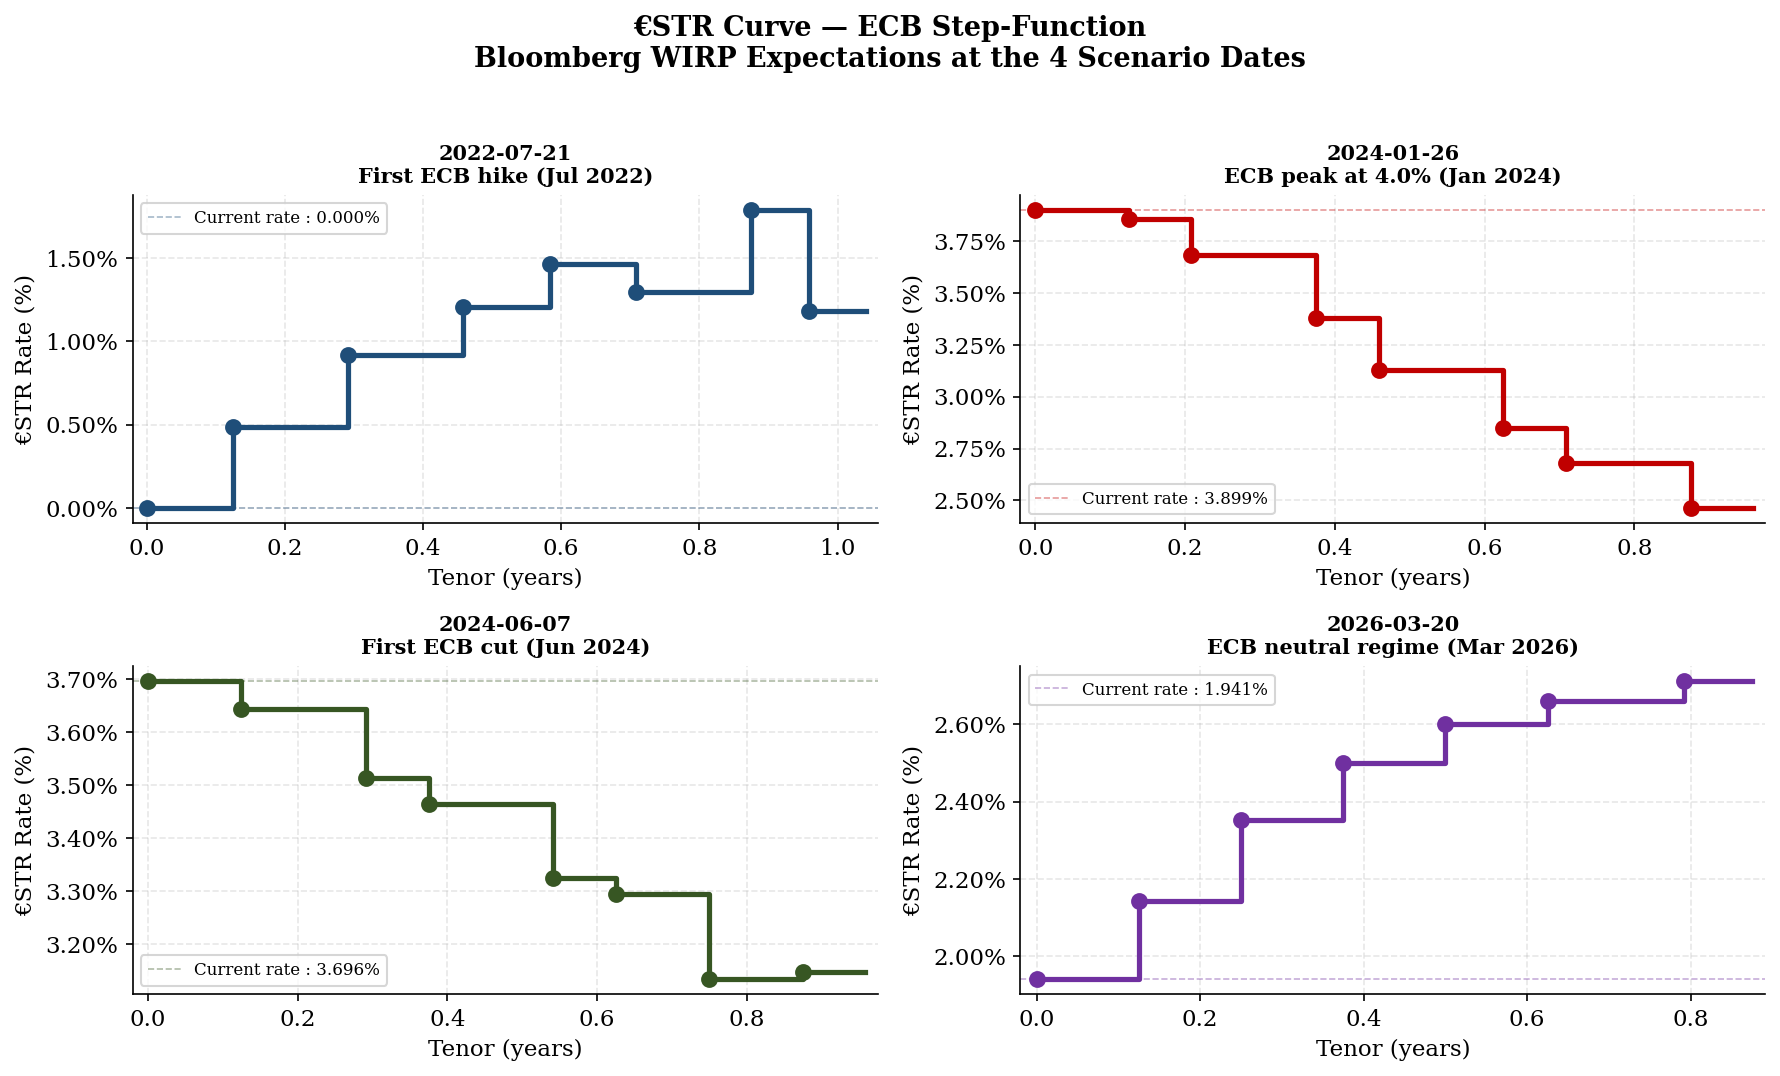

✓ Graphique A sauvegardé


In [96]:
# =============================================================================
# GRAPHIQUE A — Les 4 courbes ESTR (step-function) — 4 sous-graphiques
# =============================================================================

fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharey=False)
axes = axes.flatten()

for i, date in enumerate(DATES):
    ax = axes[i]
    w  = WIRP[date]
    dates_yrs = w['dates_yrs']
    rates     = w['rates']

    # Step-function uniquement sur la fenêtre WIRP de 12m
    x_steps, y_steps = [], []
    for j in range(len(dates_yrs)):
        t_start = dates_yrs[j]
        t_end   = dates_yrs[j + 1] if j + 1 < len(dates_yrs) else dates_yrs[-1] + 1/12
        x_steps += [t_start, t_end]
        y_steps += [rates[j], rates[j]]

    ax.plot(x_steps, y_steps,
            color=COLORS[i], linewidth=2.5)

    # Sauts verticaux entre paliers
    for j in range(len(dates_yrs) - 1):
        ax.plot([dates_yrs[j + 1], dates_yrs[j + 1]],
                [rates[j], rates[j + 1]],
                color=COLORS[i], linewidth=1.5, linestyle=':')

    # Points aux réunions BCE
    ax.scatter(dates_yrs, rates,
               color=COLORS[i], s=50, zorder=5)

    # Taux directeur courant (point de départ)
    ax.axhline(y=rates[0], color=COLORS[i], linewidth=0.8,
               linestyle='--', alpha=0.4, label=f"Current rate : {rates[0]:.3f}%")

    ax.set_title(f"{date}\n{SCENARIO_LABELS[date]}", fontweight='bold', fontsize=10)
    ax.set_xlabel("Tenor (years)")
    ax.set_ylabel("€STR Rate (%)")
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f%%'))
    ax.legend(fontsize=8)

    # Limiter l'axe x à la fenêtre WIRP + petite marge
    ax.set_xlim(-0.02, max(dates_yrs) + 0.1)

fig.suptitle("€STR Curve — ECB Step-Function\n"
             "Bloomberg WIRP Expectations at the 4 Scenario Dates",
             fontweight='bold', fontsize=13, y=1.02)

plt.tight_layout()
plt.savefig("graph_A_ESTR_stepfunction.png", bbox_inches='tight')
plt.show()
print("✓ Graphique A sauvegardé")

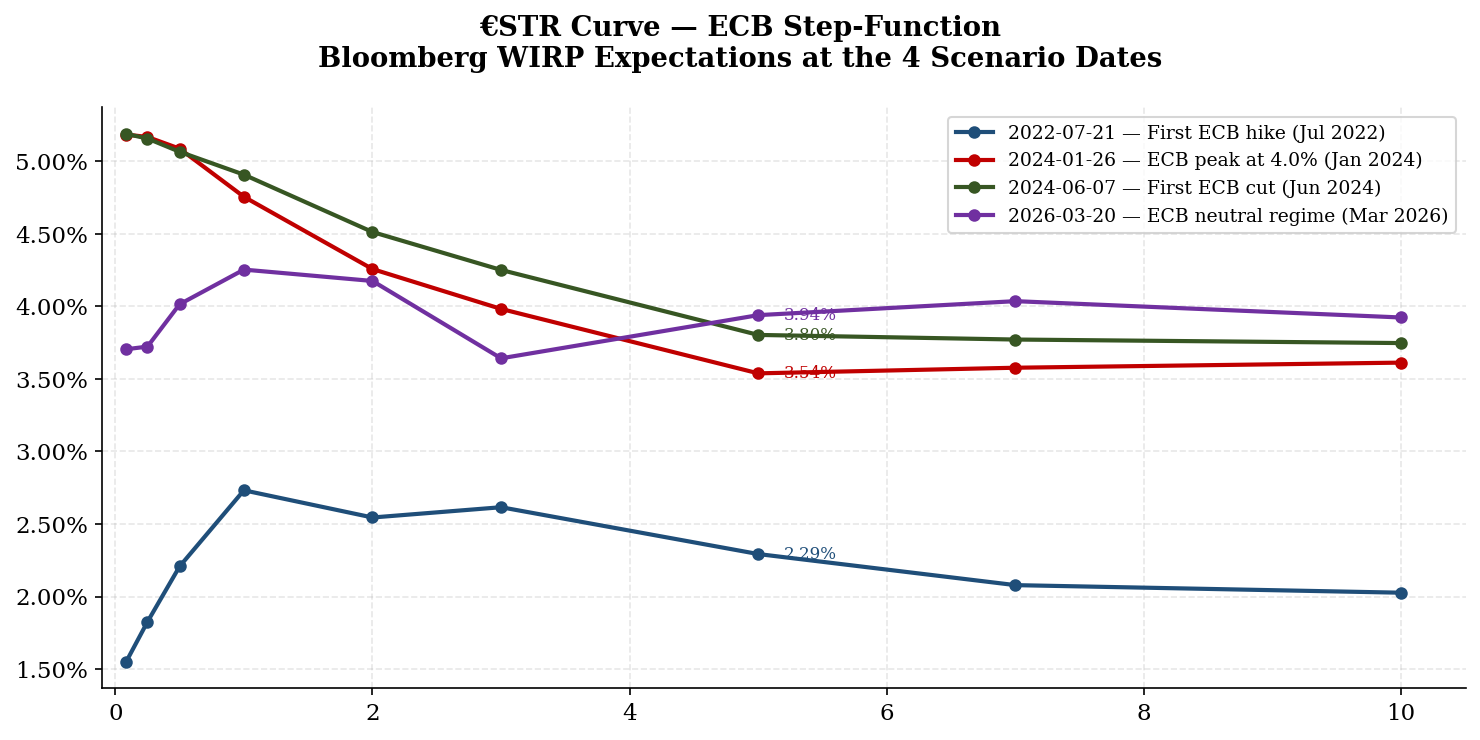

✓ Graphique B sauvegardé


In [97]:
# =============================================================================
# GRAPHIQUE B — Les 4 courbes SONIA (bootstrap OIS)
# =============================================================================

fig, ax = plt.subplots(figsize=(10, 5))

for i, date in enumerate(DATES):
    zrs = sonia_curves[date]['zr']

    ax.plot(TENORS_YRS, zrs,
            color=COLORS[i], linewidth=2,
            marker='o', markersize=5,
            label=f"{date} — {SCENARIO_LABELS[date]}")

fig.suptitle("€STR Curve — ECB Step-Function\n"
             "Bloomberg WIRP Expectations at the 4 Scenario Dates",
             fontweight='bold')
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f%%'))
ax.set_xlim(-0.1, 10.5)

# Annotation des niveaux à 5Y pour chaque scénario
for i, date in enumerate(DATES):
    zr_5y = sonia_curves[date]['zr'][6]   # index 6 = 5Y
    ax.annotate(f"{zr_5y:.2f}%",
                xy=(5, zr_5y),
                xytext=(5.2, zr_5y),
                color=COLORS[i], fontsize=8,
                va='center')

plt.tight_layout()
plt.savefig("graph_B_SONIA_bootstrap.png", bbox_inches='tight')
plt.show()
print("✓ Graphique B sauvegardé")

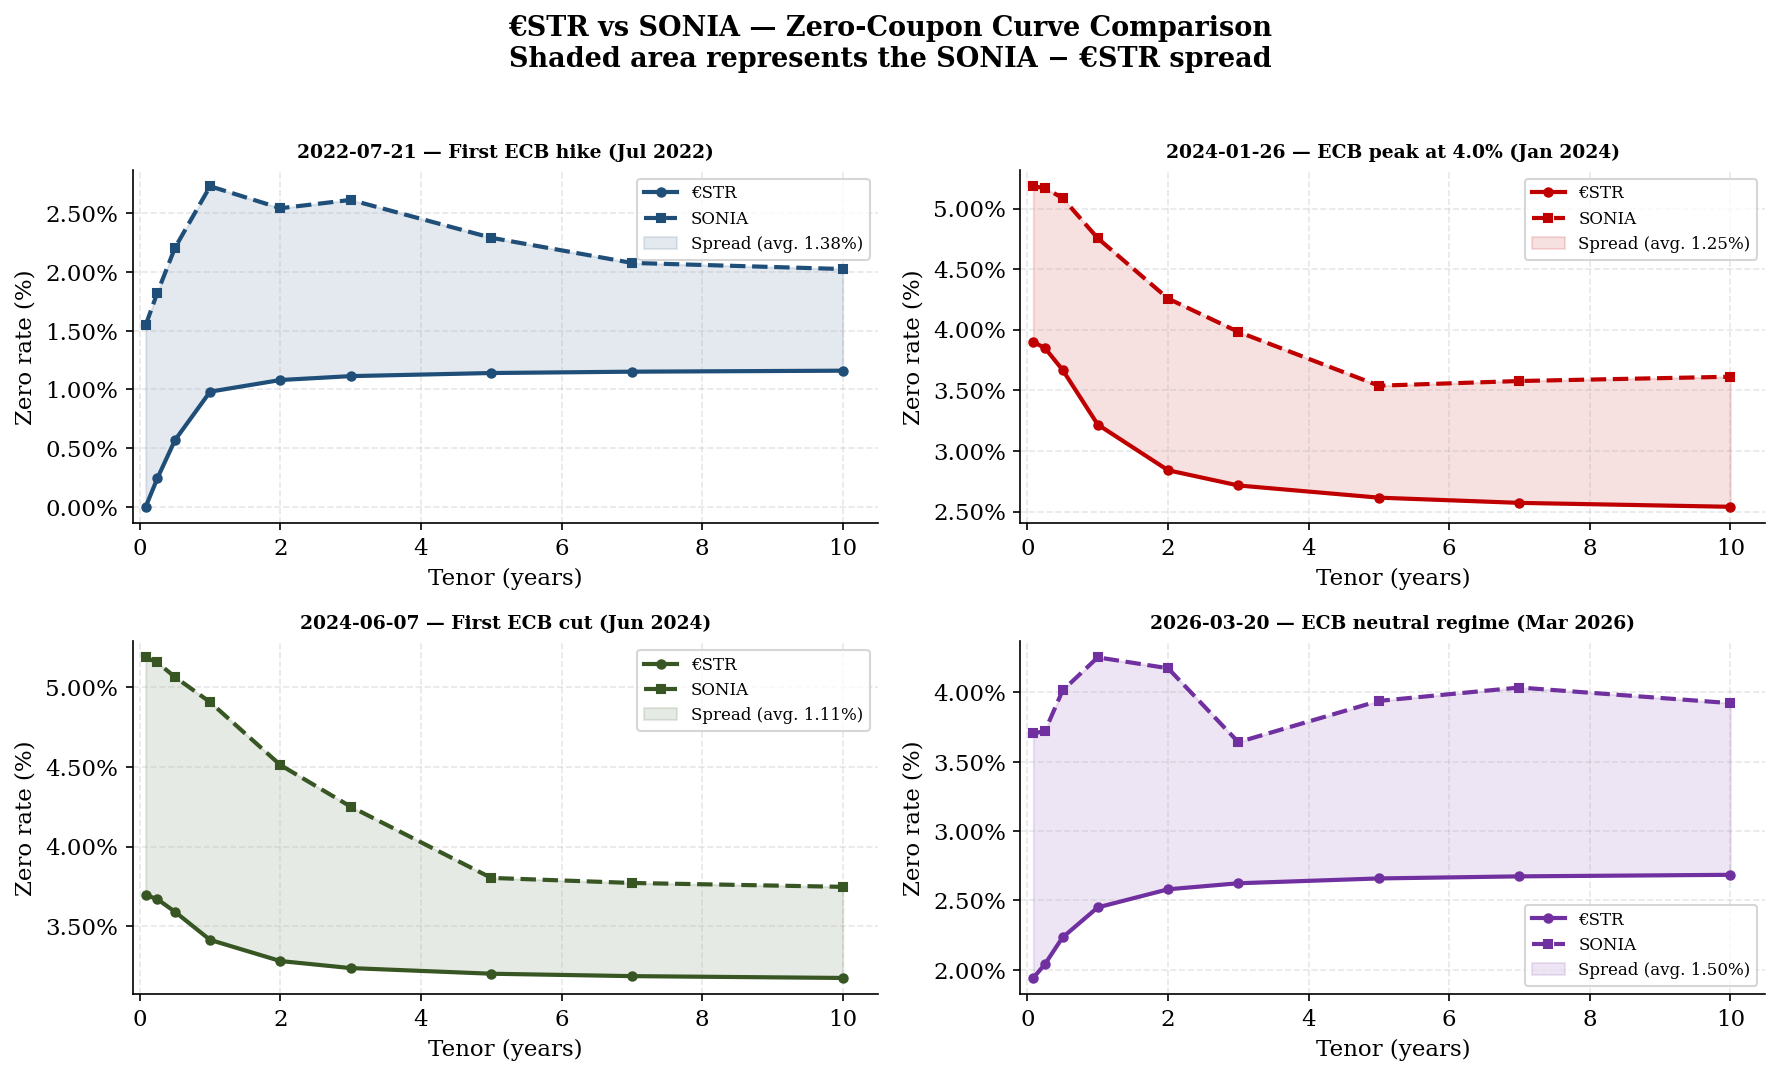

✓ Graphique C sauvegardé


In [98]:
# =============================================================================
# GRAPHIQUE C — ESTR vs SONIA côte à côte pour chaque scénario
# =============================================================================

fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharey=False)
axes = axes.flatten()

for i, date in enumerate(DATES):
    ax = axes[i]

    estr_zr  = estr_curves[date]['zr']
    sonia_zr = sonia_curves[date]['zr']
    spread   = sonia_zr - estr_zr   # spread SONIA - ESTR en %

    # ESTR et SONIA
    ax.plot(TENORS_YRS, estr_zr,
            color=COLORS[i], linewidth=2,
            marker='o', markersize=4, label='€STR')
    ax.plot(TENORS_YRS, sonia_zr,
            color=COLORS[i], linewidth=2, linestyle='--',
            marker='s', markersize=4, label='SONIA')

    # Zone de spread entre les deux courbes
    ax.fill_between(TENORS_YRS, estr_zr, sonia_zr,
                    alpha=0.12, color=COLORS[i],
                    label=f'Spread (avg. {np.mean(spread):.2f}%)')

    ax.set_title(f"{date} — {SCENARIO_LABELS[date]}",
                 fontweight='bold', fontsize=9)
    ax.set_xlabel("Tenor (years)")
    ax.set_ylabel("Zero rate (%)")
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f%%'))
    ax.legend(fontsize=8)
    ax.set_xlim(-0.1, 10.5)

fig.suptitle("€STR vs SONIA — Zero-Coupon Curve Comparison\n"
             "Shaded area represents the SONIA − €STR spread",
             fontweight='bold', fontsize=13, y=1.02)

plt.tight_layout()
plt.savefig("graph_C_ESTR_vs_SONIA.png", bbox_inches='tight')
plt.show()
print("✓ Graphique C sauvegardé")

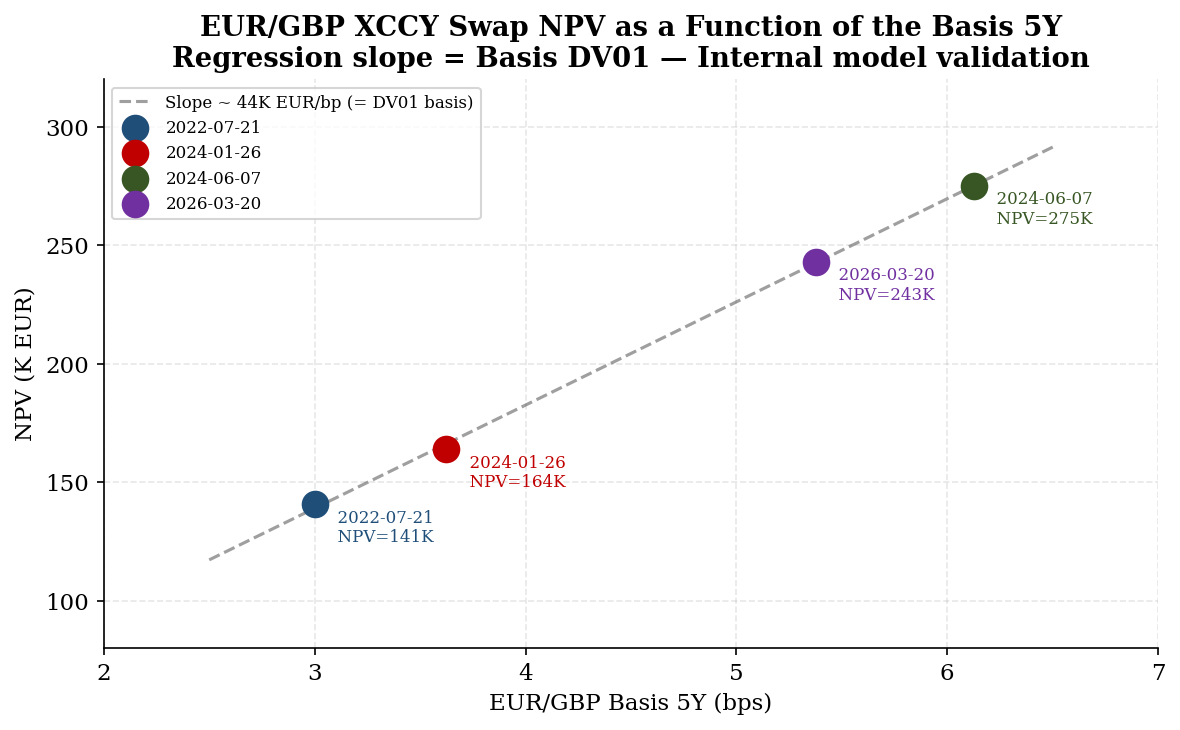

Graphique D sauvegardé


In [99]:
# =============================================================================
# GRAPHIQUE D — Scatter plot : NPV = f(Basis EUR/GBP 5Y)
# =============================================================================

fig, ax = plt.subplots(figsize=(8, 5))

npv_values   = [results[d]['NPV_EUR'] / 1000 for d in DATES]
basis_values = [data[d].loc['EURGBP_basis', '5Y'] for d in DATES]

# Droite de régression
coeffs = np.polyfit(basis_values, npv_values, 1)
x_line = np.linspace(2.5, 6.5, 100)
y_line = np.polyval(coeffs, x_line)

ax.plot(x_line, y_line,
        color='#404040', linewidth=1.5,
        linestyle='--', alpha=0.5,
        label=f'Slope ~ {coeffs[0]:.0f}K EUR/bp (= DV01 basis)')

# Points
for i, date in enumerate(DATES):
    ax.scatter(basis_values[i], npv_values[i],
               color=COLORS[i], s=150, zorder=5,
               label=date)
    ax.annotate(f"  {date}\n  NPV={npv_values[i]:.0f}K",
                xy=(basis_values[i], npv_values[i]),
                xytext=(6, -18),
                textcoords='offset points',
                fontsize=8, color=COLORS[i])

ax.set_xlabel("EUR/GBP Basis 5Y (bps)")
ax.set_ylabel("NPV (K EUR)")
ax.set_title("EUR/GBP XCCY Swap NPV as a Function of the Basis 5Y\n"
             "Regression slope = Basis DV01 — Internal model validation",
             fontweight='bold')
ax.legend(fontsize=8, loc='upper left')
ax.set_xlim(2.0, 7.0)
ax.set_ylim(80, 320)

plt.tight_layout()
plt.savefig("graph_D1_scatter.png", bbox_inches='tight')
plt.show()
print("Graphique D sauvegardé")

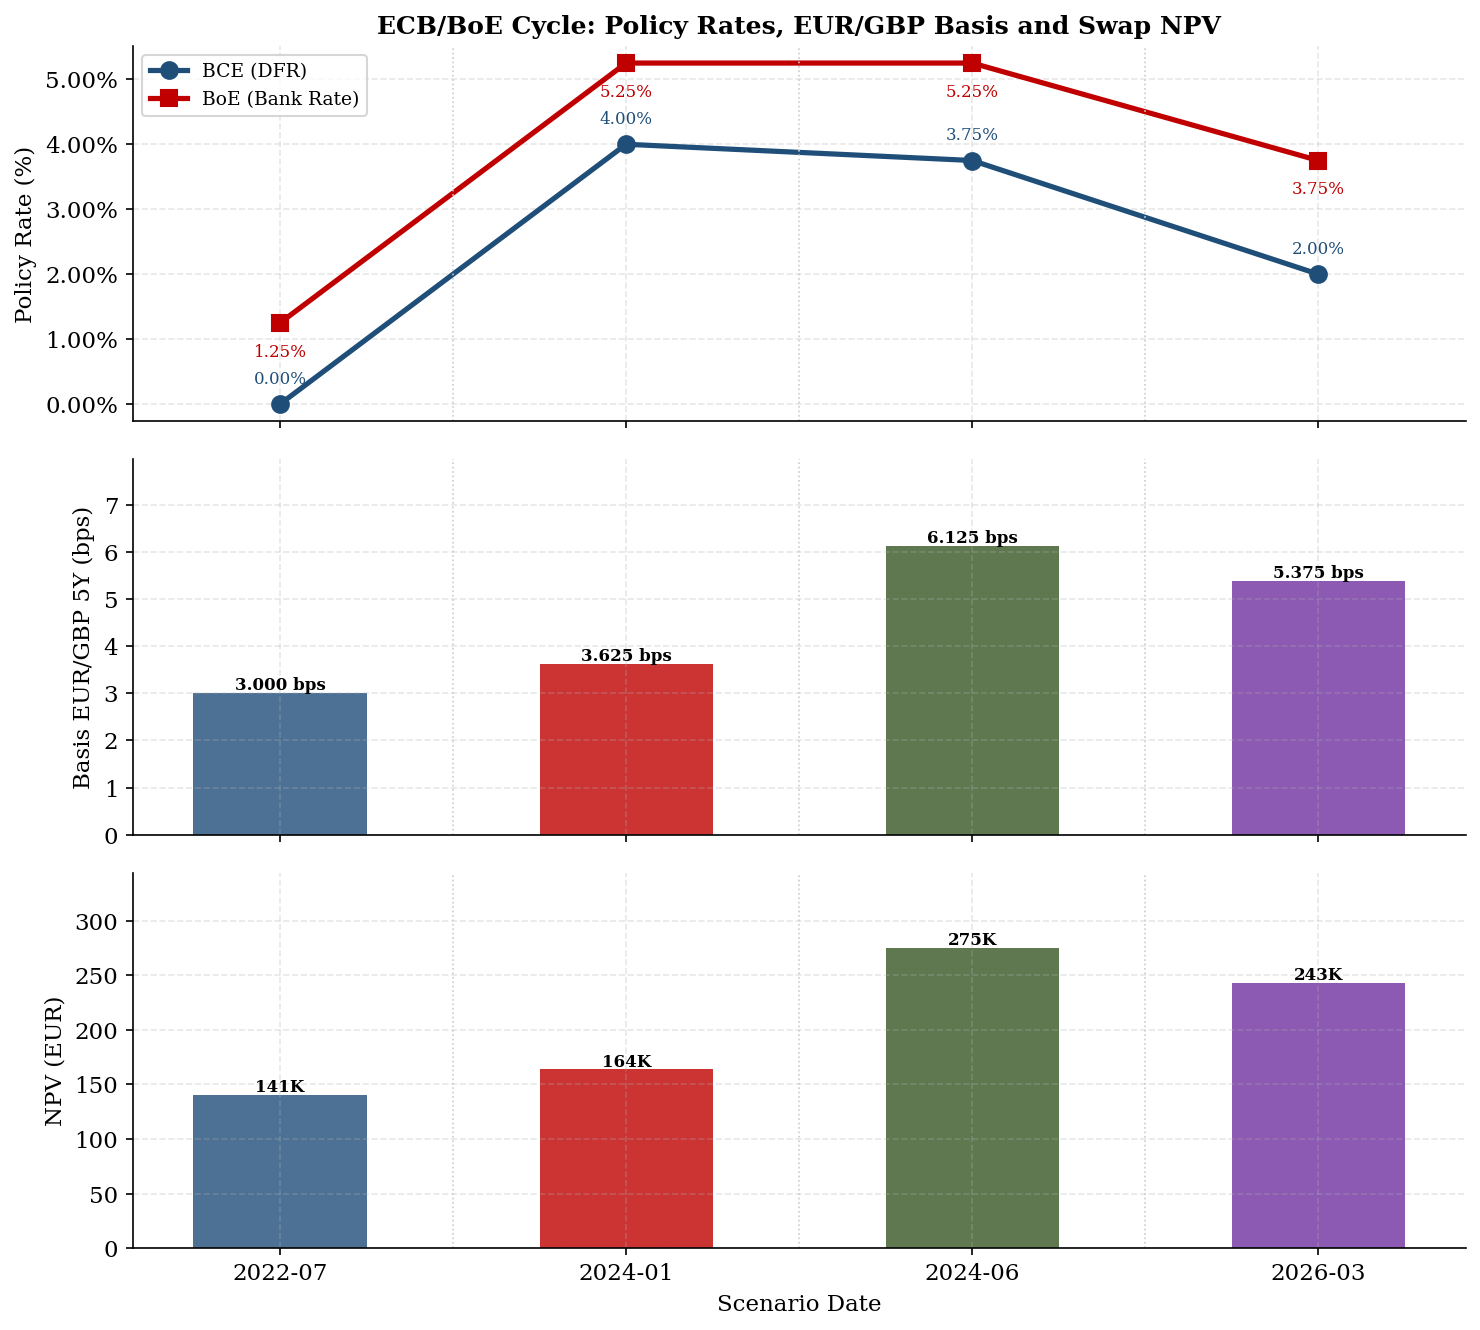

Graphique F sauvegardé


In [ ]:
# =============================================================================
# GRAPHIQUE F — Cycle BCE : NPV, Basis 5Y et taux directeurs
#               à travers les 4 scénarios
# =============================================================================

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 9), sharex=True)

x      = np.arange(len(DATES))
labels = [d[:7] for d in DATES]

npv_values   = [results[d]['NPV_EUR'] / 1000 for d in DATES]
basis_values = [data[d].loc['EURGBP_basis', '5Y'] for d in DATES]
ecb_values   = [ECB_RATES[d] for d in DATES]
boe_values   = [BOE_RATES[d] for d in DATES]

# ── Axe 1 : Taux directeurs BCE et BoE ───────────────────────────
ax1.plot(x, ecb_values, color=COLORS[0], linewidth=2.5,
         marker='o', markersize=8, label='BCE (DFR)')
ax1.plot(x, boe_values, color=COLORS[1], linewidth=2.5,
         marker='s', markersize=8, label='BoE (Bank Rate)')

for i in range(len(DATES)):
    ax1.annotate(f"{ecb_values[i]:.2f}%",
                 xy=(x[i], ecb_values[i]),
                 xytext=(0, 10), textcoords='offset points',
                 ha='center', fontsize=8, color=COLORS[0])
    ax1.annotate(f"{boe_values[i]:.2f}%",
                 xy=(x[i], boe_values[i]),
                 xytext=(0, -16), textcoords='offset points',
                 ha='center', fontsize=8, color=COLORS[1])

ax1.set_ylabel("Policy Rate (%)")
ax1.set_title("ECB/BoE Cycle: Policy Rates, EUR/GBP Basis and Swap NPV",
              fontweight='bold', fontsize=12)
ax1.legend(fontsize=9, loc='upper left')
ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f%%'))

# ── Axe 2 : Basis EUR/GBP 5Y ─────────────────────────────────────
ax2.bar(x, basis_values, color=COLORS, alpha=0.8, width=0.5)

for i in range(len(DATES)):
    ax2.text(x[i], basis_values[i] + 0.08,
             f"{basis_values[i]:.3f} bps",
             ha='center', fontsize=8, fontweight='bold')

ax2.set_ylabel("Basis EUR/GBP 5Y (bps)")
ax2.set_ylim(0, max(basis_values) * 1.3)

# ── Axe 3 : NPV ──────────────────────────────────────────────────
ax3.bar(x, npv_values, color=COLORS, alpha=0.8, width=0.5)

for i in range(len(DATES)):
    ax3.text(x[i], npv_values[i] + 3,
             f"{npv_values[i]:.0f}K",
             ha='center', fontsize=8, fontweight='bold')

ax3.set_ylabel("NPV (EUR)")
ax3.set_ylim(0, max(npv_values) * 1.25)
ax3.set_xticks(x)
ax3.set_xticklabels(labels)
ax3.set_xlabel("Scenario Date")

# Ligne séparation visuelle entre les 3 axes
for ax in [ax1, ax2, ax3]:
    ax.axvline(x=0.5, color='#cccccc', linewidth=0.8, linestyle=':')
    ax.axvline(x=1.5, color='#cccccc', linewidth=0.8, linestyle=':')
    ax.axvline(x=2.5, color='#cccccc', linewidth=0.8, linestyle=':')

plt.tight_layout()
plt.savefig("graph_F_cycle_BCE.png", bbox_inches='tight')
plt.show()
print("Graphique F sauvegardé")

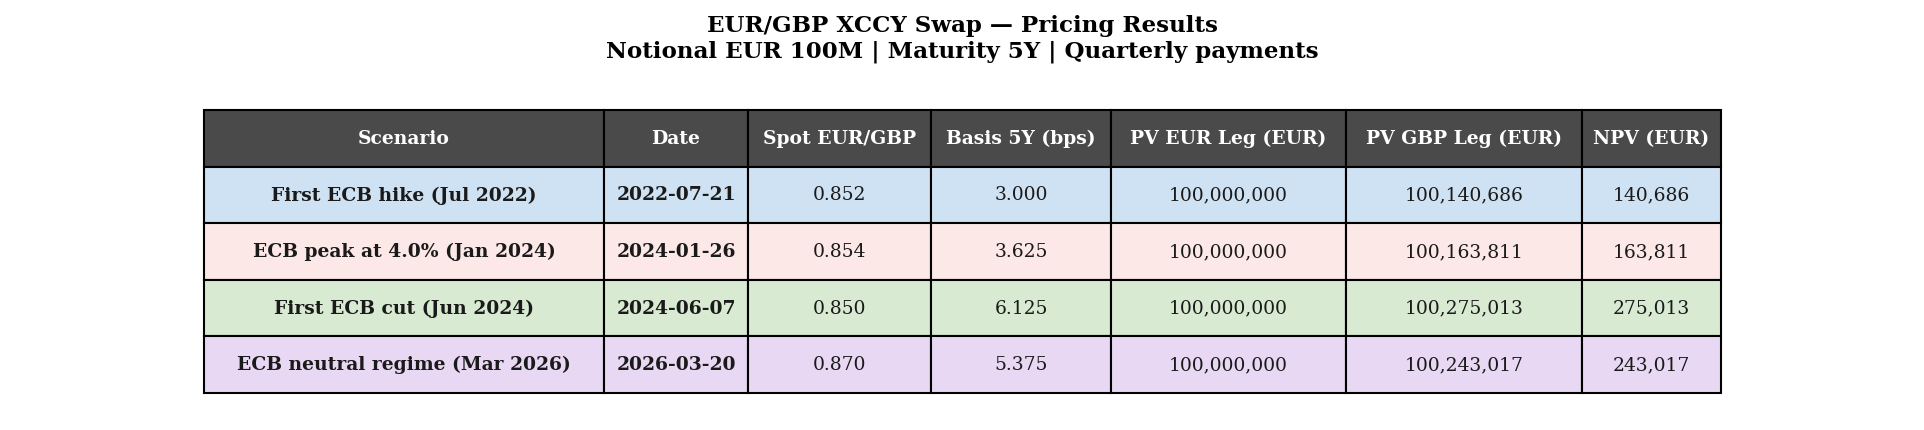

Graphique résultats sauvegardé


In [101]:
# =============================================================================
# GRAPHIQUE RÉSULTATS — Tableau des NPV par scénario 
# =============================================================================

fig, ax = plt.subplots(figsize=(13, 3))
ax.axis('off')

col_labels = ['Scenario', 'Date', 'Spot EUR/GBP',
              'Basis 5Y (bps)', 'PV EUR Leg (EUR)',
              'PV GBP Leg (EUR)', 'NPV (EUR)']

# Labels scénarios raccourcis pour éviter coupure
SCENARIO_SHORT = {
    '2022-07-21': 'First ECB hike (Jul 2022)',
    '2024-01-26': 'ECB peak at 4.0% (Jan 2024)',
    '2024-06-07': 'First ECB cut (Jun 2024)',
    '2026-03-20': 'ECB neutral regime (Mar 2026)'
}

table_data = []
for date in DATES:
    r        = results[date]
    basis_5y = data[date].loc['EURGBP_basis', '5Y']
    table_data.append([
        SCENARIO_SHORT[date],
        date,
        f"{SPOTS[date]:.3f}",
        f"{basis_5y:.3f}",
        f"{r['PV_EUR_leg']:,.0f}",
        f"{r['PV_GBP_leg']:,.0f}",
        f"{r['NPV_EUR']:,.0f}",
    ])

# Couleurs par scénario
PASTEL_COLORS = [
    '#cfe2f3',   # bleu pastel
    '#fce8e6',   # rouge pastel
    '#d9ead3',   # vert pastel
    '#e9d8f4',   # violet pastel
]

table = ax.table(
    cellText = table_data,
    colLabels = col_labels,
    cellLoc  = 'center',
    loc      = 'center',
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 2.4)

# Largeur colonne 0 plus grande pour éviter coupure
table.auto_set_column_width([0, 1, 2, 3, 4, 5, 6])

# Header
for j in range(len(col_labels)):
    table[0, j].set_facecolor("#4B4A4A")
    table[0, j].set_text_props(color='white', fontweight='bold')

# Lignes
for i in range(len(DATES)):
    for j in range(len(col_labels)):
        table[i + 1, j].set_facecolor(PASTEL_COLORS[i])
        table[i + 1, j].set_text_props(color='#1a1a1a')
    # Colonne scénario en légèrement plus foncé
    table[i + 1, 0].set_text_props(color='#1a1a1a', fontweight='bold')
    table[i + 1, 1].set_text_props(color='#1a1a1a', fontweight='bold')

ax.set_title("EUR/GBP XCCY Swap — Pricing Results\n"
             "Notional EUR 100M | Maturity 5Y | Quarterly payments",
             fontweight='bold', fontsize=11, pad=15)

plt.tight_layout()
plt.savefig("graph_results_table.png", bbox_inches='tight', dpi=200)
plt.show()
print("Graphique résultats sauvegardé")